# Evaluating Classifiers: From Confusion Matrices to ROC Curves

A classifier that scores documents (spam/ham, relevant/not) is not the same as
a decision. The threshold you choose turns scores into decisions, and different
thresholds produce different trade-offs. This demo builds that understanding
from confusion matrices through to ROC curves and AUC.

**Learning goals:**
- Read and interpret a confusion matrix
- Compute precision, recall, specificity, and accuracy from counts
- Understand why accuracy misleads with imbalanced classes
- Sweep a score threshold and observe how metrics change
- Construct an ROC curve step by step from scored examples
- Compute AUC and compare it across classifiers with different score separation

**Prerequisites:** Section 2.2 (precision/recall basics from ch02-01)

In [1]:
from shared.display import print_table, display_md
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

## The Scenario: A Spam Filter

We have 20 emails. A spam filter assigns each a continuous score between 0 and 1
(higher = more likely spam). We also know the true label. The question: at what
threshold should we call an email "spam"?

This is the same 20-email filter used in the textbook (Section 2.6). It is
deliberately hard: several spam messages score low and several legitimate
messages score high, so the two score distributions overlap in the 0.30 to 0.55
range. No threshold separates them cleanly.

In [2]:
# 20 emails with spam scores and true labels (textbook Section 2.6).
# Spam and ham scores overlap in the 0.30-0.55 band, so the classifier
# cannot separate the classes with any single threshold.
EMAILS = [
    {"id": 1,  "subject": "FREE VIAGRA BUY NOW!!!",              "score": 0.90, "label": "spam"},
    {"id": 2,  "subject": "You won $1,000,000!",                 "score": 0.80, "label": "spam"},
    {"id": 3,  "subject": "URGENT: server outage needs action",  "score": 0.70, "label": "ham"},
    {"id": 4,  "subject": "Discount medications online",         "score": 0.60, "label": "spam"},
    {"id": 5,  "subject": "Enlarge your portfolio today",        "score": 0.55, "label": "spam"},
    {"id": 6,  "subject": "Limited time investment offer",       "score": 0.54, "label": "spam"},
    {"id": 7,  "subject": "Conference registration closing soon","score": 0.53, "label": "ham"},
    {"id": 8,  "subject": "Reminder: submit your expense report","score": 0.52, "label": "ham"},
    {"id": 9,  "subject": "Act now, exclusive deal",             "score": 0.51, "label": "spam"},
    {"id": 10, "subject": "Win a seat at the team raffle",       "score": 0.50, "label": "ham"},
    {"id": 11, "subject": "Claim your reward points",            "score": 0.40, "label": "spam"},
    {"id": 12, "subject": "Project deadline reminder",           "score": 0.39, "label": "ham"},
    {"id": 13, "subject": "Your package could not be delivered", "score": 0.38, "label": "spam"},
    {"id": 14, "subject": "Re: your application",                "score": 0.37, "label": "ham"},
    {"id": 15, "subject": "Quarterly report attached",           "score": 0.36, "label": "ham"},
    {"id": 16, "subject": "Budget spreadsheet updated",          "score": 0.35, "label": "ham"},
    {"id": 17, "subject": "Re: invoice attached",                "score": 0.34, "label": "spam"},
    {"id": 18, "subject": "Sprint retrospective agenda",         "score": 0.33, "label": "ham"},
    {"id": 19, "subject": "Quick question about your account",   "score": 0.30, "label": "spam"},
    {"id": 20, "subject": "Lunch plans?",                        "score": 0.10, "label": "ham"},
]

# Show the dataset sorted by score
rows = []
for e in sorted(EMAILS, key=lambda x: x["score"], reverse=True):
    rows.append([e["id"], e["subject"][:35], f"{e['score']:.2f}", e["label"]])

print_table(rows, headers=["ID", "Subject", "Score", "True Label"])

|   ID | Subject                             |   Score | True Label   |
|-----:|:------------------------------------|--------:|:-------------|
|    1 | FREE VIAGRA BUY NOW!!!              |    0.9  | spam         |
|    2 | You won $1,000,000!                 |    0.8  | spam         |
|    3 | URGENT: server outage needs action  |    0.7  | ham          |
|    4 | Discount medications online         |    0.6  | spam         |
|    5 | Enlarge your portfolio today        |    0.55 | spam         |
|    6 | Limited time investment offer       |    0.54 | spam         |
|    7 | Conference registration closing soo |    0.53 | ham          |
|    8 | Reminder: submit your expense repor |    0.52 | ham          |
|    9 | Act now, exclusive deal             |    0.51 | spam         |
|   10 | Win a seat at the team raffle       |    0.5  | ham          |
|   11 | Claim your reward points            |    0.4  | spam         |
|   12 | Project deadline reminder           |    0.39 | ham          |
|   13 | Your package could not be delivered |    0.38 | spam         |
|   14 | Re: your application                |    0.37 | ham          |
|   15 | Quarterly report attached           |    0.36 | ham          |
|   16 | Budget spreadsheet updated          |    0.35 | ham          |
|   17 | Re: invoice attached                |    0.34 | spam         |
|   18 | Sprint retrospective agenda         |    0.33 | ham          |
|   19 | Quick question about your account   |    0.3  | spam         |
|   20 | Lunch plans?                        |    0.1  | ham          |

---
## 1. Confusion Matrix Basics

Let us pick a threshold of 0.5 and classify everything at or above as "spam".
The confusion matrix shows the four possible outcomes.

In [3]:
def classify(emails, threshold):
    """Classify emails as spam (positive) or ham (negative) at a given threshold."""
    tp, fp, fn, tn = 0, 0, 0, 0
    for e in emails:
        predicted_spam = e["score"] >= threshold
        actual_spam = e["label"] == "spam"
        if predicted_spam and actual_spam:
            tp += 1
        elif predicted_spam and not actual_spam:
            fp += 1
        elif not predicted_spam and actual_spam:
            fn += 1
        else:
            tn += 1
    return tp, fp, fn, tn

# At threshold = 0.5
tp, fp, fn, tn = classify(EMAILS, threshold=0.5)

display_md(
    f"**Confusion Matrix at threshold = 0.5:**\n\n"
    f"|  | Predicted Spam | Predicted Ham |\n"
    f"|--|---------------|---------------|\n"
    f"| **Actual Spam** | TP = {tp} | FN = {fn} |\n"
    f"| **Actual Ham** | FP = {fp} | TN = {tn} |"
)

**Confusion Matrix at threshold = 0.5:**

|  | Predicted Spam | Predicted Ham |
|--|---------------|---------------|
| **Actual Spam** | TP = 6 | FN = 4 |
| **Actual Ham** | FP = 4 | TN = 6 |

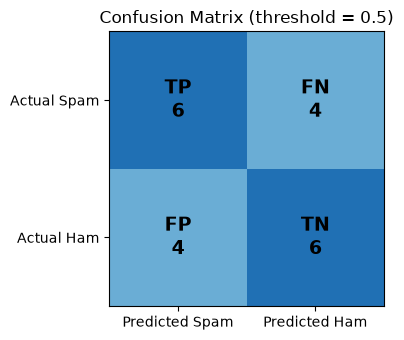

In [4]:
# Visualize the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(4, 3.5))
matrix = [[tp, fn], [fp, tn]]
im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(tp, fp, fn, tn) + 2)

# Annotate cells
labels = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{matrix[i][j]}",
                ha="center", va="center", fontsize=14, fontweight="bold")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Predicted Spam", "Predicted Ham"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual Spam", "Actual Ham"])
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

At threshold 0.5 the filter makes real mistakes: it flags four legitimate
emails as spam (FP) and lets four spam messages through (FN). Because the
dataset is balanced (10 spam, 10 ham) and 0.5 splits it down the middle,
precision, recall, and accuracy all land at 0.6. That is barely better than a
coin flip, which is exactly the point: the scores overlap, so no threshold is
comfortable. Section 4 sweeps the threshold to find a better operating point.

---
## 2. Derived Metrics

From the four counts we derive all common classification metrics.

In [5]:
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # also called sensitivity/TPR
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # true negative rate
accuracy = (tp + tn) / (tp + fp + fn + tn)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # false positive rate = 1 minus specificity

print_table(
    [
        ["Precision", "TP / (TP + FP)", f"{tp} / ({tp} + {fp})", f"{precision:.3f}"],
        ["Recall (Sensitivity)", "TP / (TP + FN)", f"{tp} / ({tp} + {fn})", f"{recall:.3f}"],
        ["Specificity", "TN / (TN + FP)", f"{tn} / ({tn} + {fp})", f"{specificity:.3f}"],
        ["Accuracy", "(TP+TN) / All", f"({tp}+{tn}) / {tp+fp+fn+tn}", f"{accuracy:.3f}"],
        ["False Positive Rate", "FP / (FP + TN)", f"{fp} / ({fp} + {tn})", f"{fpr:.3f}"],
    ],
    headers=["Metric", "Formula", "Calculation", "Value"],
)

| Metric               | Formula        | Calculation   |   Value |
|:---------------------|:---------------|:--------------|--------:|
| Precision            | TP / (TP + FP) | 6 / (6 + 4)   |     0.6 |
| Recall (Sensitivity) | TP / (TP + FN) | 6 / (6 + 4)   |     0.6 |
| Specificity          | TN / (TN + FP) | 6 / (6 + 4)   |     0.6 |
| Accuracy             | (TP+TN) / All  | (6+6) / 20    |     0.6 |
| False Positive Rate  | FP / (FP + TN) | 4 / (4 + 6)   |     0.4 |

In [6]:
display_md(
    "**Precision** tells us: of emails we *flagged* as spam, what fraction truly was spam?\n\n"
    "**Recall** tells us: of emails that *were* spam, what fraction did we catch?\n\n"
    "**Specificity** tells us: of emails that were *not* spam, what fraction did we correctly leave alone?"
)

**Precision** tells us: of emails we *flagged* as spam, what fraction truly was spam?

**Recall** tells us: of emails that *were* spam, what fraction did we catch?

**Specificity** tells us: of emails that were *not* spam, what fraction did we correctly leave alone?

---
## 3. The Accuracy Paradox

Accuracy can be dangerously misleading with imbalanced classes. Imagine a
different dataset where only 5% of emails are spam.

In [7]:
# Simulated imbalanced scenario: 95 ham, 5 spam
# A "predict all ham" classifier:
tp_lazy, fp_lazy, fn_lazy, tn_lazy = 0, 0, 5, 95
acc_lazy = (tp_lazy + tn_lazy) / 100
prec_lazy = 0  # never predicts spam
rec_lazy = 0   # never catches spam

display_md(
    f"**Imbalanced dataset:** 95 ham, 5 spam\n\n"
    f"**'Predict all ham' classifier:**\n\n"
    f"| Metric | Value |\n"
    f"|--------|-------|\n"
    f"| Accuracy | {acc_lazy:.0%} |\n"
    f"| Precision (spam) | {prec_lazy:.0%} |\n"
    f"| Recall (spam) | {rec_lazy:.0%} |\n\n"
    f"95% accuracy! Sounds great, until you realize it catches **zero** spam.\n\n"
    f"**Lesson:** Accuracy alone is dangerous. Always report precision and recall "
    f"for the class you care about."
)

**Imbalanced dataset:** 95 ham, 5 spam

**'Predict all ham' classifier:**

| Metric | Value |
|--------|-------|
| Accuracy | 95% |
| Precision (spam) | 0% |
| Recall (spam) | 0% |

95% accuracy! Sounds great, until you realize it catches **zero** spam.

**Lesson:** Accuracy alone is dangerous. Always report precision and recall for the class you care about.

---
## 4. Threshold Sweep

The spam score is continuous, so where we draw the line determines the
trade-off. Let us sweep the threshold from 0 to 1 and watch precision, recall,
and FPR change.

In [8]:
# Sweep thresholds
thresholds = sorted(set(e["score"] for e in EMAILS)) + [0.0, 1.0]
thresholds = sorted(set(thresholds))

sweep_results = []
for t in thresholds:
    tp_t, fp_t, fn_t, tn_t = classify(EMAILS, t)
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 1.0
    rec_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0.0
    acc_t = (tp_t + tn_t) / 20
    sweep_results.append({
        "threshold": t, "tp": tp_t, "fp": fp_t, "fn": fn_t, "tn": tn_t,
        "precision": prec_t, "recall": rec_t, "fpr": fpr_t, "accuracy": acc_t
    })

# Show a few key thresholds, including the textbook landmarks 0.38, 0.54, 0.70
key_thresholds = [0.0, 0.30, 0.38, 0.50, 0.54, 0.70, 1.0]
rows = []
for r in sweep_results:
    if r["threshold"] in key_thresholds:
        rows.append([
            f"{r['threshold']:.2f}",
            f"{r['precision']:.3f}",
            f"{r['recall']:.3f}",
            f"{r['fpr']:.3f}",
            f"{r['accuracy']:.3f}",
        ])

print_table(rows, headers=["Threshold", "Precision", "Recall", "FPR", "Accuracy"])

|   Threshold |   Precision |   Recall |   FPR |   Accuracy |
|------------:|------------:|---------:|------:|-----------:|
|        0    |       0.5   |      1   |   1   |       0.5  |
|        0.3  |       0.526 |      1   |   0.9 |       0.55 |
|        0.38 |       0.615 |      0.8 |   0.5 |       0.65 |
|        0.5  |       0.6   |      0.6 |   0.4 |       0.6  |
|        0.54 |       0.833 |      0.5 |   0.1 |       0.7  |
|        0.7  |       0.667 |      0.2 |   0.1 |       0.55 |
|        1    |       1     |      0   |   0   |       0.5  |

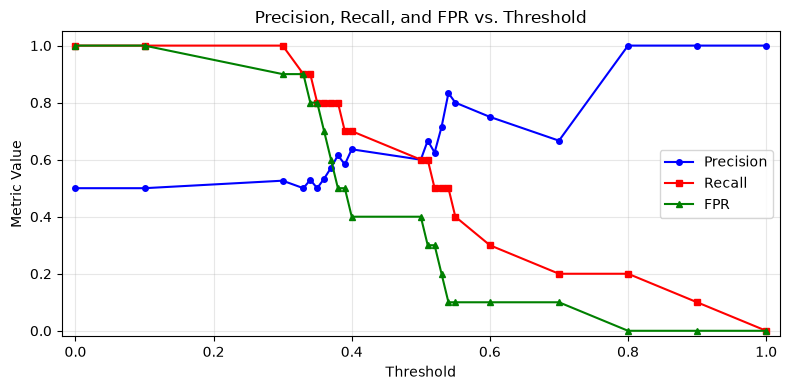

In [9]:
# Plot precision, recall, and FPR as functions of threshold
fig, ax = plt.subplots(figsize=(8, 4))

ts = [r["threshold"] for r in sweep_results]
ax.plot(ts, [r["precision"] for r in sweep_results], "b-o", markersize=4, label="Precision")
ax.plot(ts, [r["recall"] for r in sweep_results], "r-s", markersize=4, label="Recall")
ax.plot(ts, [r["fpr"] for r in sweep_results], "g-^", markersize=4, label="FPR")

ax.set_xlabel("Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Precision, Recall, and FPR vs. Threshold")
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

In [10]:
display_md(
    "**Observation:** As we raise the threshold, we become more conservative:\n\n"
    "- **Precision increases** (fewer false alarms)\n"
    "- **Recall decreases** (we miss more spam)\n"
    "- **FPR decreases** (fewer legitimate emails incorrectly flagged)\n\n"
    "Threshold 0.54 reaches the highest accuracy (0.70): it catches half the spam "
    "(recall 0.50) while flagging only one legitimate email (FPR 0.10). This is the "
    "operating point highlighted in the textbook. Even so, half the spam still gets "
    "through, because the scores overlap. There is no threshold that is both precise "
    "and complete."
)

**Observation:** As we raise the threshold, we become more conservative:

- **Precision increases** (fewer false alarms)
- **Recall decreases** (we miss more spam)
- **FPR decreases** (fewer legitimate emails incorrectly flagged)

Threshold 0.54 reaches the highest accuracy (0.70): it catches half the spam (recall 0.50) while flagging only one legitimate email (FPR 0.10). This is the operating point highlighted in the textbook. Even so, half the spam still gets through, because the scores overlap. There is no threshold that is both precise and complete.

---
## 5. ROC Curve Construction

The **ROC curve** (Receiver Operating Characteristic) plots True Positive Rate
(recall) against False Positive Rate at every threshold. It separates model
quality from the threshold decision.

We build it by sorting emails from highest to lowest score and lowering the
threshold one email at a time. Each spam email steps the curve up (TPR rises);
each legitimate email steps it right (FPR rises).

In [11]:
# Step-by-step construction for the textbook filter
sorted_emails = sorted(EMAILS, key=lambda e: e["score"], reverse=True)
total_spam = sum(1 for e in EMAILS if e["label"] == "spam")
total_ham = sum(1 for e in EMAILS if e["label"] == "ham")

rows = []
tp_count = 0
fp_count = 0
for e in sorted_emails:
    if e["label"] == "spam":
        tp_count += 1
    else:
        fp_count += 1
    fn_count = total_spam - tp_count
    tn_count = total_ham - fp_count
    tpr = tp_count / total_spam
    fpr = fp_count / total_ham
    acc = (tp_count + tn_count) / len(EMAILS)
    marker = "  <- best accuracy" if abs(e["score"] - 0.54) < 1e-9 else ""
    rows.append([f"{e['score']:.2f}{marker}", e["label"], tp_count, fp_count,
                 fn_count, tn_count, f"{tpr:.2f}", f"{fpr:.2f}", f"{acc:.2f}"])

print_table(rows, headers=["Score (T)", "Class", "TP", "FP", "FN", "TN", "TPR", "FPR", "ACC"])

| Score (T)              | Class   |   TP |   FP |   FN |   TN |   TPR |   FPR |   ACC |
|:-----------------------|:--------|-----:|-----:|-----:|-----:|------:|------:|------:|
| 0.90                   | spam    |    1 |    0 |    9 |   10 |   0.1 |   0   |  0.55 |
| 0.80                   | spam    |    2 |    0 |    8 |   10 |   0.2 |   0   |  0.6  |
| 0.70                   | ham     |    2 |    1 |    8 |    9 |   0.2 |   0.1 |  0.55 |
| 0.60                   | spam    |    3 |    1 |    7 |    9 |   0.3 |   0.1 |  0.6  |
| 0.55                   | spam    |    4 |    1 |    6 |    9 |   0.4 |   0.1 |  0.65 |
| 0.54  <- best accuracy | spam    |    5 |    1 |    5 |    9 |   0.5 |   0.1 |  0.7  |
| 0.53                   | ham     |    5 |    2 |    5 |    8 |   0.5 |   0.2 |  0.65 |
| 0.52                   | ham     |    5 |    3 |    5 |    7 |   0.5 |   0.3 |  0.6  |
| 0.51                   | spam    |    6 |    3 |    4 |    7 |   0.6 |   0.3 |  0.65 |
| 0.50                   | ham     |    6 |    4 |    4 |    6 |   0.6 |   0.4 |  0.6  |
| 0.40                   | spam    |    7 |    4 |    3 |    6 |   0.7 |   0.4 |  0.65 |
| 0.39                   | ham     |    7 |    5 |    3 |    5 |   0.7 |   0.5 |  0.6  |
| 0.38                   | spam    |    8 |    5 |    2 |    5 |   0.8 |   0.5 |  0.65 |
| 0.37                   | ham     |    8 |    6 |    2 |    4 |   0.8 |   0.6 |  0.6  |
| 0.36                   | ham     |    8 |    7 |    2 |    3 |   0.8 |   0.7 |  0.55 |
| 0.35                   | ham     |    8 |    8 |    2 |    2 |   0.8 |   0.8 |  0.5  |
| 0.34                   | spam    |    9 |    8 |    1 |    2 |   0.9 |   0.8 |  0.55 |
| 0.33                   | ham     |    9 |    9 |    1 |    1 |   0.9 |   0.9 |  0.5  |
| 0.30                   | spam    |   10 |    9 |    0 |    1 |   1   |   0.9 |  0.55 |
| 0.10                   | ham     |   10 |   10 |    0 |    0 |   1   |   1   |  0.5  |

The highlighted row at T = 0.54 gives TPR = 0.50, FPR = 0.10, accuracy = 0.70:
the highest-accuracy threshold, matching the textbook figure. Notice how the
curve stalls in the middle (several rows raise FPR without raising TPR) wherever
a legitimate email outscores the remaining spam.

### Compare scenarios

The shape of the ROC curve depends entirely on how well the scores separate the
two classes. Use the dropdown to compare the textbook filter against three other
score distributions.

In [12]:
# Each scenario is a set of spam and ham scores. The textbook filter is the default.
SCENARIOS = {
    "Overlapping (textbook)": {
        "spam": [0.90, 0.80, 0.60, 0.55, 0.54, 0.51, 0.40, 0.38, 0.34, 0.30],
        "ham":  [0.70, 0.53, 0.52, 0.50, 0.39, 0.37, 0.36, 0.35, 0.33, 0.10],
    },
    "Strong classifier": {
        "spam": [0.92, 0.85, 0.78, 0.70, 0.62, 0.55, 0.48, 0.42, 0.35, 0.28],
        "ham":  [0.58, 0.50, 0.45, 0.38, 0.32, 0.25, 0.20, 0.15, 0.10, 0.05],
    },
    "Perfect separation": {
        "spam": [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.52],
        "ham":  [0.48, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05],
    },
    "No discrimination": {
        "spam": [0.90, 0.75, 0.60, 0.50, 0.45, 0.35, 0.30, 0.20, 0.15, 0.05],
        "ham":  [0.85, 0.70, 0.65, 0.55, 0.40, 0.38, 0.25, 0.22, 0.12, 0.10],
    },
}

def make_emails(scenario):
    """Build a labelled email list from a scenario's spam/ham score lists."""
    spec = SCENARIOS[scenario]
    return (
        [{"score": s, "label": "spam"} for s in spec["spam"]]
        + [{"score": s, "label": "ham"} for s in spec["ham"]]
    )

def roc_points(emails):
    """Cumulative (FPR, TPR) points, sweeping the threshold from high to low."""
    ordered = sorted(emails, key=lambda e: e["score"], reverse=True)
    n_spam = sum(1 for e in emails if e["label"] == "spam")
    n_ham = len(emails) - n_spam
    pts = [(0.0, 0.0)]
    tp = fp = 0
    for e in ordered:
        if e["label"] == "spam":
            tp += 1
        else:
            fp += 1
        pts.append((fp / n_ham, tp / n_spam))
    return pts

def auc(pts):
    """Area under the ROC curve via the trapezoidal rule."""
    return sum((pts[i][0] - pts[i - 1][0]) * (pts[i][1] + pts[i - 1][1]) / 2
               for i in range(1, len(pts)))

def show_roc(scenario):
    """Plot the ROC curve for the selected scenario and report its AUC."""
    pts = roc_points(make_emails(scenario))
    area = auc(pts)
    fprs = [p[0] for p in pts]
    tprs = [p[1] for p in pts]

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.plot(fprs, tprs, "b-o", markersize=5, linewidth=2, label=f"AUC = {area:.2f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.5)")
    ax.fill_between(fprs, tprs, alpha=0.1)
    ax.plot(0, 1, "g*", markersize=15)
    ax.annotate("Perfect\n(0,1)", (0, 1), textcoords="offset points", xytext=(10, -15))

    ax.set_xlabel("False Positive Rate (1 minus Specificity)")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(f"ROC Curve: {scenario}")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

The textbook filter's ROC curve is shown below as a static reference (it always
renders, even on GitHub). The dropdown after it lets you swap in the other
scenarios when you run the notebook yourself.

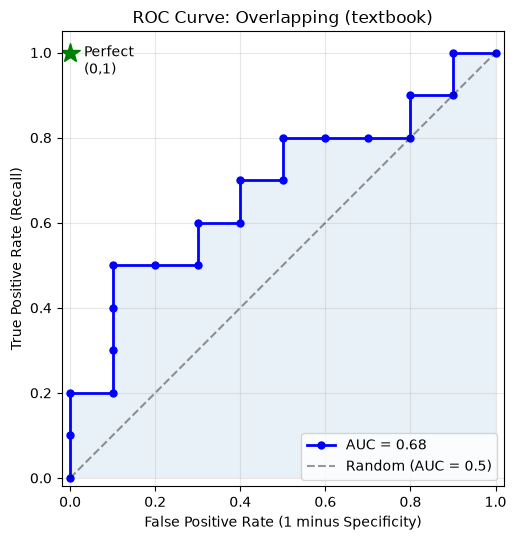

In [13]:
# Static reference: the textbook filter (also the widget's default)
show_roc("Overlapping (textbook)")

In [14]:
widgets.interact(
    show_roc,
    scenario=widgets.Dropdown(
        options=list(SCENARIOS),
        value="Overlapping (textbook)",
        description="Scenario:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="450px"),
    ),
);

interactive(children=(Dropdown(description='Scenario:', layout=Layout(width='450px'), options=('Overlapping (t…

In [15]:
display_md(
    "**Reading the ROC curve:**\n\n"
    "- The curve lives in [0,1] x [0,1]. Points closer to (0,1) are better.\n"
    "- The diagonal represents a random classifier (coin flip).\n"
    "- A curve that hugs the top-left corner indicates a strong model.\n\n"
    "The textbook filter does *not* hug the corner: it rises steeply at first "
    "(the two highest-scoring emails are spam) but then flattens as legitimate "
    "emails start outscoring spam. Switch to **Perfect separation** to see the "
    "ideal curve reach (0,1), or **No discrimination** to see it collapse onto "
    "the diagonal."
)

**Reading the ROC curve:**

- The curve lives in [0,1] x [0,1]. Points closer to (0,1) are better.
- The diagonal represents a random classifier (coin flip).
- A curve that hugs the top-left corner indicates a strong model.

The textbook filter does *not* hug the corner: it rises steeply at first (the two highest-scoring emails are spam) but then flattens as legitimate emails start outscoring spam. Switch to **Perfect separation** to see the ideal curve reach (0,1), or **No discrimination** to see it collapse onto the diagonal.

---
## 6. AUC: Area Under the ROC Curve

AUC summarizes the entire ROC curve in a single number. It equals the
probability that a randomly chosen positive example receives a higher score
than a randomly chosen negative example.

In [16]:
# AUC for the textbook filter
textbook_auc = auc(roc_points(make_emails("Overlapping (textbook)")))

display_md(
    f"**Textbook filter AUC = {textbook_auc:.2f}**\n\n"
    f"Interpretation: if we pick a random spam email and a random legitimate "
    f"email, there is a {textbook_auc:.0%} chance the spam email gets the higher "
    f"score. The imperfect separation comes from the emails scored in the "
    f"0.30 to 0.55 band, where the two classes overlap heavily."
)

**Textbook filter AUC = 0.68**

Interpretation: if we pick a random spam email and a random legitimate email, there is a 68% chance the spam email gets the higher score. The imperfect separation comes from the emails scored in the 0.30 to 0.55 band, where the two classes overlap heavily.

In [17]:
# Compare AUC across all scenarios
rows = []
for name in SCENARIOS:
    rows.append([name, f"{auc(roc_points(make_emails(name))):.2f}"])

print_table(rows, headers=["Scenario", "AUC"])

| Scenario               |   AUC |
|:-----------------------|------:|
| Overlapping (textbook) |  0.68 |
| Strong classifier      |  0.85 |
| Perfect separation     |  1    |
| No discrimination      |  0.5  |

In [18]:
display_md(
    "| AUC Range | Quality |\n"
    "|-----------|----------|\n"
    "| 0.90 to 1.00 | Excellent |\n"
    "| 0.80 to 0.90 | Good |\n"
    "| 0.70 to 0.80 | Fair |\n"
    "| 0.50 to 0.70 | Poor |\n"
    "| 0.50 | Random (no discrimination) |\n\n"
    "The textbook filter lands in the 'poor' band: its scores carry some signal, "
    "but not enough to place a clean threshold."
)

| AUC Range | Quality |
|-----------|----------|
| 0.90 to 1.00 | Excellent |
| 0.80 to 0.90 | Good |
| 0.70 to 0.80 | Fair |
| 0.50 to 0.70 | Poor |
| 0.50 | Random (no discrimination) |

The textbook filter lands in the 'poor' band: its scores carry some signal, but not enough to place a clean threshold.

In [19]:
# Verify the textbook AUC by counting concordant pairs (Mann-Whitney U statistic)
spam_scores = [e["score"] for e in EMAILS if e["label"] == "spam"]
ham_scores = [e["score"] for e in EMAILS if e["label"] == "ham"]

concordant = 0
total_pairs = 0
for s in spam_scores:
    for h in ham_scores:
        total_pairs += 1
        if s > h:
            concordant += 1
        elif s == h:
            concordant += 0.5  # ties count as half

auc_counting = concordant / total_pairs

display_md(
    f"**Verification (counting concordant pairs):**\n\n"
    f"- Spam-ham pairs: {total_pairs}\n"
    f"- Concordant (spam scored higher): {concordant:.0f}\n"
    f"- AUC = {concordant:.0f} / {total_pairs} = {auc_counting:.2f}\n\n"
    f"Both methods agree: AUC = {auc_counting:.2f}"
)

**Verification (counting concordant pairs):**

- Spam-ham pairs: 100
- Concordant (spam scored higher): 68
- AUC = 68 / 100 = 0.68

Both methods agree: AUC = 0.68

---
## Summary

In [20]:
print_table(
    [
        ["Confusion Matrix", "Counts at one threshold", "Understanding error types"],
        ["Precision / Recall", "Class-specific performance", "Imbalanced classes"],
        ["Accuracy", "Overall correctness", "Only when classes are balanced"],
        ["Threshold Sweep", "Trade-off visualization", "Choosing an operating point"],
        ["ROC Curve", "Model quality across all thresholds", "Comparing classifiers"],
        ["AUC", "Single-number summary", "Model selection, ranking quality"],
    ],
    headers=["Concept", "What It Shows", "Use When"],
)

| Concept            | What It Shows                       | Use When                         |
|:-------------------|:------------------------------------|:---------------------------------|
| Confusion Matrix   | Counts at one threshold             | Understanding error types        |
| Precision / Recall | Class-specific performance          | Imbalanced classes               |
| Accuracy           | Overall correctness                 | Only when classes are balanced   |
| Threshold Sweep    | Trade-off visualization             | Choosing an operating point      |
| ROC Curve          | Model quality across all thresholds | Comparing classifiers            |
| AUC                | Single-number summary               | Model selection, ranking quality |

In [21]:
display_md(
    "**Key takeaway:** A classifier's score is not a decision; the threshold is "
    "a business choice. ROC curves separate model quality from the decision policy. "
    "AUC tells you how well the model *ranks* examples, independent of where you "
    "draw the line. When the curve is poor (as with the textbook filter), the fix "
    "is a better model, not a better threshold."
)

**Key takeaway:** A classifier's score is not a decision; the threshold is a business choice. ROC curves separate model quality from the decision policy. AUC tells you how well the model *ranks* examples, independent of where you draw the line. When the curve is poor (as with the textbook filter), the fix is a better model, not a better threshold.

---
## Try It Yourself

1. **Move the threshold:** At what threshold does the textbook filter achieve the best F1 score? Is it the same as the best-accuracy threshold (0.54)?
2. **Cost analysis:** If a missed spam costs $1 and a false alarm (deleting a real email) costs $10, what threshold minimizes total cost?
3. **Build your own scenario:** Add a fifth entry to `SCENARIOS` and view its ROC curve. Can you design scores that give AUC around 0.75?
4. **Below the diagonal:** What would the ROC curve look like if the classifier's scores were *reversed* (spam scored low, ham scored high)? What is the AUC then?

In [22]:
# Starter: find the threshold that maximizes F1 on the textbook filter
best_f1 = 0
best_threshold = 0

for r in sweep_results:
    if r["precision"] + r["recall"] > 0:
        f1 = 2 * r["precision"] * r["recall"] / (r["precision"] + r["recall"])
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = r["threshold"]

display_md(
    f"**Best F1 = {best_f1:.3f}** at threshold = {best_threshold:.2f}\n\n"
    f"Compare this to the best-accuracy threshold (0.54). Then try computing the "
    f"cost-optimal threshold as exercise 2."
)

**Best F1 = 0.696** at threshold = 0.38

Compare this to the best-accuracy threshold (0.54). Then try computing the cost-optimal threshold as exercise 2.